# Vascular Segmentation: Data Preparation

E:\Kaisho_vascular_annotation の22枚の眼底画像＋血管アノテーションマスクを
lens検出→クロップ→リサイズして学習用データセットを準備する。

## Pipeline
1. RT-DETR でlens領域を検出
2. 画像をlens bboxでクロップ＋円形マスク適用
3. マスクも同じbbox（2倍スケール）でクロップ→バイナリ化
4. 512×512にリサイズして保存
5. QC可視化

In [ ]:
import os
import sys
import cv2
import numpy as np
from pathlib import Path
from ultralytics import RTDETR
import matplotlib.pyplot as plt
from typing import Optional, Tuple

# Paths
PROJECT_ROOT = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project')
ANNOTATION_DIR = Path(r'E:\Kaisho_vascular_annotation\Human_Annotation')
IMG_DIR = ANNOTATION_DIR / 'images'
MASK_DIR = ANNOTATION_DIR / 'masks'
OUTPUT_DIR = PROJECT_ROOT / 'vascular_segmentation' / 'data'
OUTPUT_IMG_DIR = OUTPUT_DIR / 'images'
OUTPUT_MASK_DIR = OUTPUT_DIR / 'masks'
OUTPUT_CIRCLE_DIR = OUTPUT_DIR / 'circle_masks'

RTDETR_MODEL_PATH = PROJECT_ROOT / 'models' / 'rtdetr-l-1697_1703.pt'
TARGET_SIZE = 512

for d in [OUTPUT_IMG_DIR, OUTPUT_MASK_DIR, OUTPUT_CIRCLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Images: {len(list(IMG_DIR.glob("*.png")))} files')
print(f'Masks: {len(list(MASK_DIR.glob("*.png")))} files')

## 1. Lens Detection Functions

infer_case_video.py から再利用する関数群

In [2]:
def pick_best_lens_bbox(det_results) -> Optional[np.ndarray]:
    """RT-DETR結果から Lens(cls=0) bbox(xyxy) を1つ選ぶ（conf最大を優先）。"""
    best = None
    best_conf = -1.0
    for r in det_results:
        if r.boxes is None or len(r.boxes) == 0:
            continue
        boxes = r.boxes
        cls_ids = boxes.cls.detach().cpu().numpy().astype(int)
        confs = boxes.conf.detach().cpu().numpy() if boxes.conf is not None else None
        xyxy = boxes.xyxy.detach().cpu().numpy()
        for i in range(len(cls_ids)):
            if int(cls_ids[i]) != 0:
                continue
            conf = float(confs[i]) if confs is not None else 0.0
            if conf > best_conf:
                best_conf = conf
                best = xyxy[i]
    return best


def clamp_xyxy(xyxy: np.ndarray, w: int, h: int) -> Tuple[int, int, int, int]:
    x1, y1, x2, y2 = [int(c) for c in xyxy]
    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(0, min(x2, w))
    y2 = max(0, min(y2, h))
    if x2 <= x1:
        x2 = min(w, x1 + 1)
    if y2 <= y1:
        y2 = min(h, y1 + 1)
    return x1, y1, x2, y2


def apply_circular_mask_to_crop(crop_bgr: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """円形マスク（クロップ内中心・直径=(w+h)/2）を適用。"""
    h, w = crop_bgr.shape[:2]
    center_x, center_y = w // 2, h // 2
    diameter = (w + h) / 2.0
    radius = int(diameter / 2.0)
    circle_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(circle_mask, (center_x, center_y), radius, 255, -1)
    masked = crop_bgr.copy()
    masked[circle_mask == 0] = (114, 114, 114)
    return masked, circle_mask

## 2. Lens Detection + Crop + Mask Alignment

In [3]:
# Load RT-DETR model
rtdetr = RTDETR(str(RTDETR_MODEL_PATH))
print(f'RT-DETR model loaded: {RTDETR_MODEL_PATH.name}')

RT-DETR model loaded: rtdetr-l-1697_1703.pt


In [4]:
image_files = sorted(IMG_DIR.glob('*.png'))
results_log = []

for img_path in image_files:
    fname = img_path.name
    mask_path = MASK_DIR / fname
    
    if not mask_path.exists():
        print(f'WARNING: mask not found for {fname}, skipping')
        continue
    
    # --- Read image ---
    img_bgr = cv2.imread(str(img_path))
    img_h, img_w = img_bgr.shape[:2]
    
    # --- Read mask (RGBA, 2x resolution) ---
    mask_rgba = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    mask_h, mask_w = mask_rgba.shape[:2]
    
    # --- Lens detection ---
    det = rtdetr.predict(img_bgr, verbose=False)
    bbox = pick_best_lens_bbox(det)
    
    if bbox is None:
        # Fallback: use entire image
        print(f'WARNING: No lens detected for {fname}, using full image')
        x1, y1, x2, y2 = 0, 0, img_w, img_h
    else:
        x1, y1, x2, y2 = clamp_xyxy(bbox, img_w, img_h)
    
    # --- Crop image ---
    crop_bgr = img_bgr[y1:y2, x1:x2]
    masked_crop, circle_mask = apply_circular_mask_to_crop(crop_bgr)
    
    # --- Crop mask at 2x scale ---
    scale_x = mask_w / img_w
    scale_y = mask_h / img_h
    mx1 = int(x1 * scale_x)
    my1 = int(y1 * scale_y)
    mx2 = int(x2 * scale_x)
    my2 = int(y2 * scale_y)
    mask_crop = mask_rgba[my1:my2, mx1:mx2]
    
    # --- Binarize mask: Red channel (BGRA→R is index 2) ---
    # vessel = Red(R=255,G=0,B=0), background = White(255,255,255)
    # In BGRA: vessel = (0,0,255,255), bg = (255,255,255,255)
    # Simple: G==0 and B==0 means vessel
    g_ch = mask_crop[:, :, 1]  # Green channel
    b_ch = mask_crop[:, :, 0]  # Blue channel (cv2 BGRA)
    vessel_binary = ((g_ch == 0) & (b_ch == 0)).astype(np.uint8) * 255
    
    # --- Resize mask to match crop size ---
    crop_h, crop_w = crop_bgr.shape[:2]
    vessel_resized = cv2.resize(vessel_binary, (crop_w, crop_h), interpolation=cv2.INTER_NEAREST)
    
    # --- Apply circle mask to vessel mask ---
    vessel_resized[circle_mask == 0] = 0
    
    # --- Resize to TARGET_SIZE ---
    img_512 = cv2.resize(masked_crop, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_LINEAR)
    mask_512 = cv2.resize(vessel_resized, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_NEAREST)
    circle_512 = cv2.resize(circle_mask, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_NEAREST)
    
    # --- Save ---
    stem = img_path.stem
    cv2.imwrite(str(OUTPUT_IMG_DIR / f'{stem}.png'), img_512)
    cv2.imwrite(str(OUTPUT_MASK_DIR / f'{stem}.png'), mask_512)
    cv2.imwrite(str(OUTPUT_CIRCLE_DIR / f'{stem}.png'), circle_512)
    
    vessel_pct = 100 * np.sum(mask_512 > 0) / np.sum(circle_512 > 0) if np.sum(circle_512 > 0) > 0 else 0
    results_log.append({
        'filename': fname,
        'img_shape': f'{img_h}x{img_w}',
        'bbox': f'({x1},{y1},{x2},{y2})',
        'crop_shape': f'{crop_h}x{crop_w}',
        'vessel_pct': f'{vessel_pct:.2f}%',
        'lens_detected': bbox is not None
    })
    print(f'{fname}: crop={crop_h}x{crop_w}, vessel={vessel_pct:.2f}%, lens={bbox is not None}')

print(f'\nProcessed {len(results_log)}/{len(image_files)} images')
print(f'Output: {OUTPUT_DIR}')

0E900037-CE07-405C-82A4-5293EB2FC8F4.png: crop=757x757, vessel=4.69%, lens=True
1C329021-715D-46B5-97AF-864952A86DF7.png: crop=685x690, vessel=1.62%, lens=True
204B89BA-5864-4D89-AFE1-D23D2D906D17.png: crop=760x703, vessel=1.05%, lens=True
286D9676-12C2-4026-A53D-73BD94502021.png: crop=745x747, vessel=4.26%, lens=True
30A0F797-DEFD-4137-A11A-7E3529A7E0D4.png: crop=717x719, vessel=0.70%, lens=True
366E2260-EAA3-4CB5-BA99-690D5CDA75B2.png: crop=773x702, vessel=12.02%, lens=True
56EF17CB-DDE0-4255-A0C8-2C8F555A355A.png: crop=597x589, vessel=9.49%, lens=True
5B763EC2-CBE6-4E3C-8D9C-999235458767.png: crop=699x682, vessel=8.07%, lens=True
6B193D74-82AE-4FAC-9DB2-D6DA4DBB56A6.png: crop=641x639, vessel=6.38%, lens=True
6F6D768A-21F5-4CAC-85EB-D87D6C092968.png: crop=762x792, vessel=8.80%, lens=True
6FB55DC4-4899-43AA-B4DE-D10CB5DAC929.png: crop=690x692, vessel=8.50%, lens=True
7BA9B019-0851-427D-868A-EC84E1FC1C4C.png: crop=731x732, vessel=10.29%, lens=True
7E4ADD96-1DFC-4B0D-84B8-F0A438327284.p

## 3. Summary Statistics

In [5]:
import pandas as pd

df_log = pd.DataFrame(results_log)
print(f'Total images processed: {len(df_log)}')
print(f'Lens detected: {df_log["lens_detected"].sum()}/{len(df_log)}')
print(f'\nVessel pixel % within circle mask:')
vessel_pcts = df_log['vessel_pct'].str.rstrip('%').astype(float)
print(f'  Mean: {vessel_pcts.mean():.2f}%')
print(f'  Min:  {vessel_pcts.min():.2f}%')
print(f'  Max:  {vessel_pcts.max():.2f}%')
print()
df_log

Total images processed: 22
Lens detected: 22/22

Vessel pixel % within circle mask:
  Mean: 5.86%
  Min:  0.70%
  Max:  12.15%



,filename,img_shape,bbox,crop_shape,vessel_pct,lens_detected
0,0E900037-CE07-405C-82A4-5293EB2FC8F4.png,1920x1080,"(164,601,921,1358)",757x757,4.69%,True
1,1C329021-715D-46B5-97AF-864952A86DF7.png,1920x1080,"(120,806,810,1491)",685x690,1.62%,True
2,204B89BA-5864-4D89-AFE1-D23D2D906D17.png,1080x1920,"(474,16,1177,776)",760x703,1.05%,True
3,286D9676-12C2-4026-A53D-73BD94502021.png,1920x1080,"(142,652,889,1397)",745x747,4.26%,True
4,30A0F797-DEFD-4137-A11A-7E3529A7E0D4.png,1920x1080,"(213,604,932,1321)",717x719,0.70%,True
5,366E2260-EAA3-4CB5-BA99-690D5CDA75B2.png,1920x1080,"(6,425,708,1198)",773x702,12.02%,True
6,56EF17CB-DDE0-4255-A0C8-2C8F555A355A.png,1920x1080,"(68,534,657,1131)",597x589,9.49%,True
7,5B763EC2-CBE6-4E3C-8D9C-999235458767.png,1920x1080,"(257,559,939,1258)",699x682,8.07%,True
8,6B193D74-82AE-4FAC-9DB2-D6DA4DBB56A6.png,1920x1080,"(185,680,824,1321)",641x639,6.38%,True
9,6F6D768A-21F5-4CAC-85EB-D87D6C092968.png,1920x1080,"(67,534,859,1296)",762x792,8.80%,True


## 4. QC Visualization

全22ペアのオーバーレイ表示で品質確認

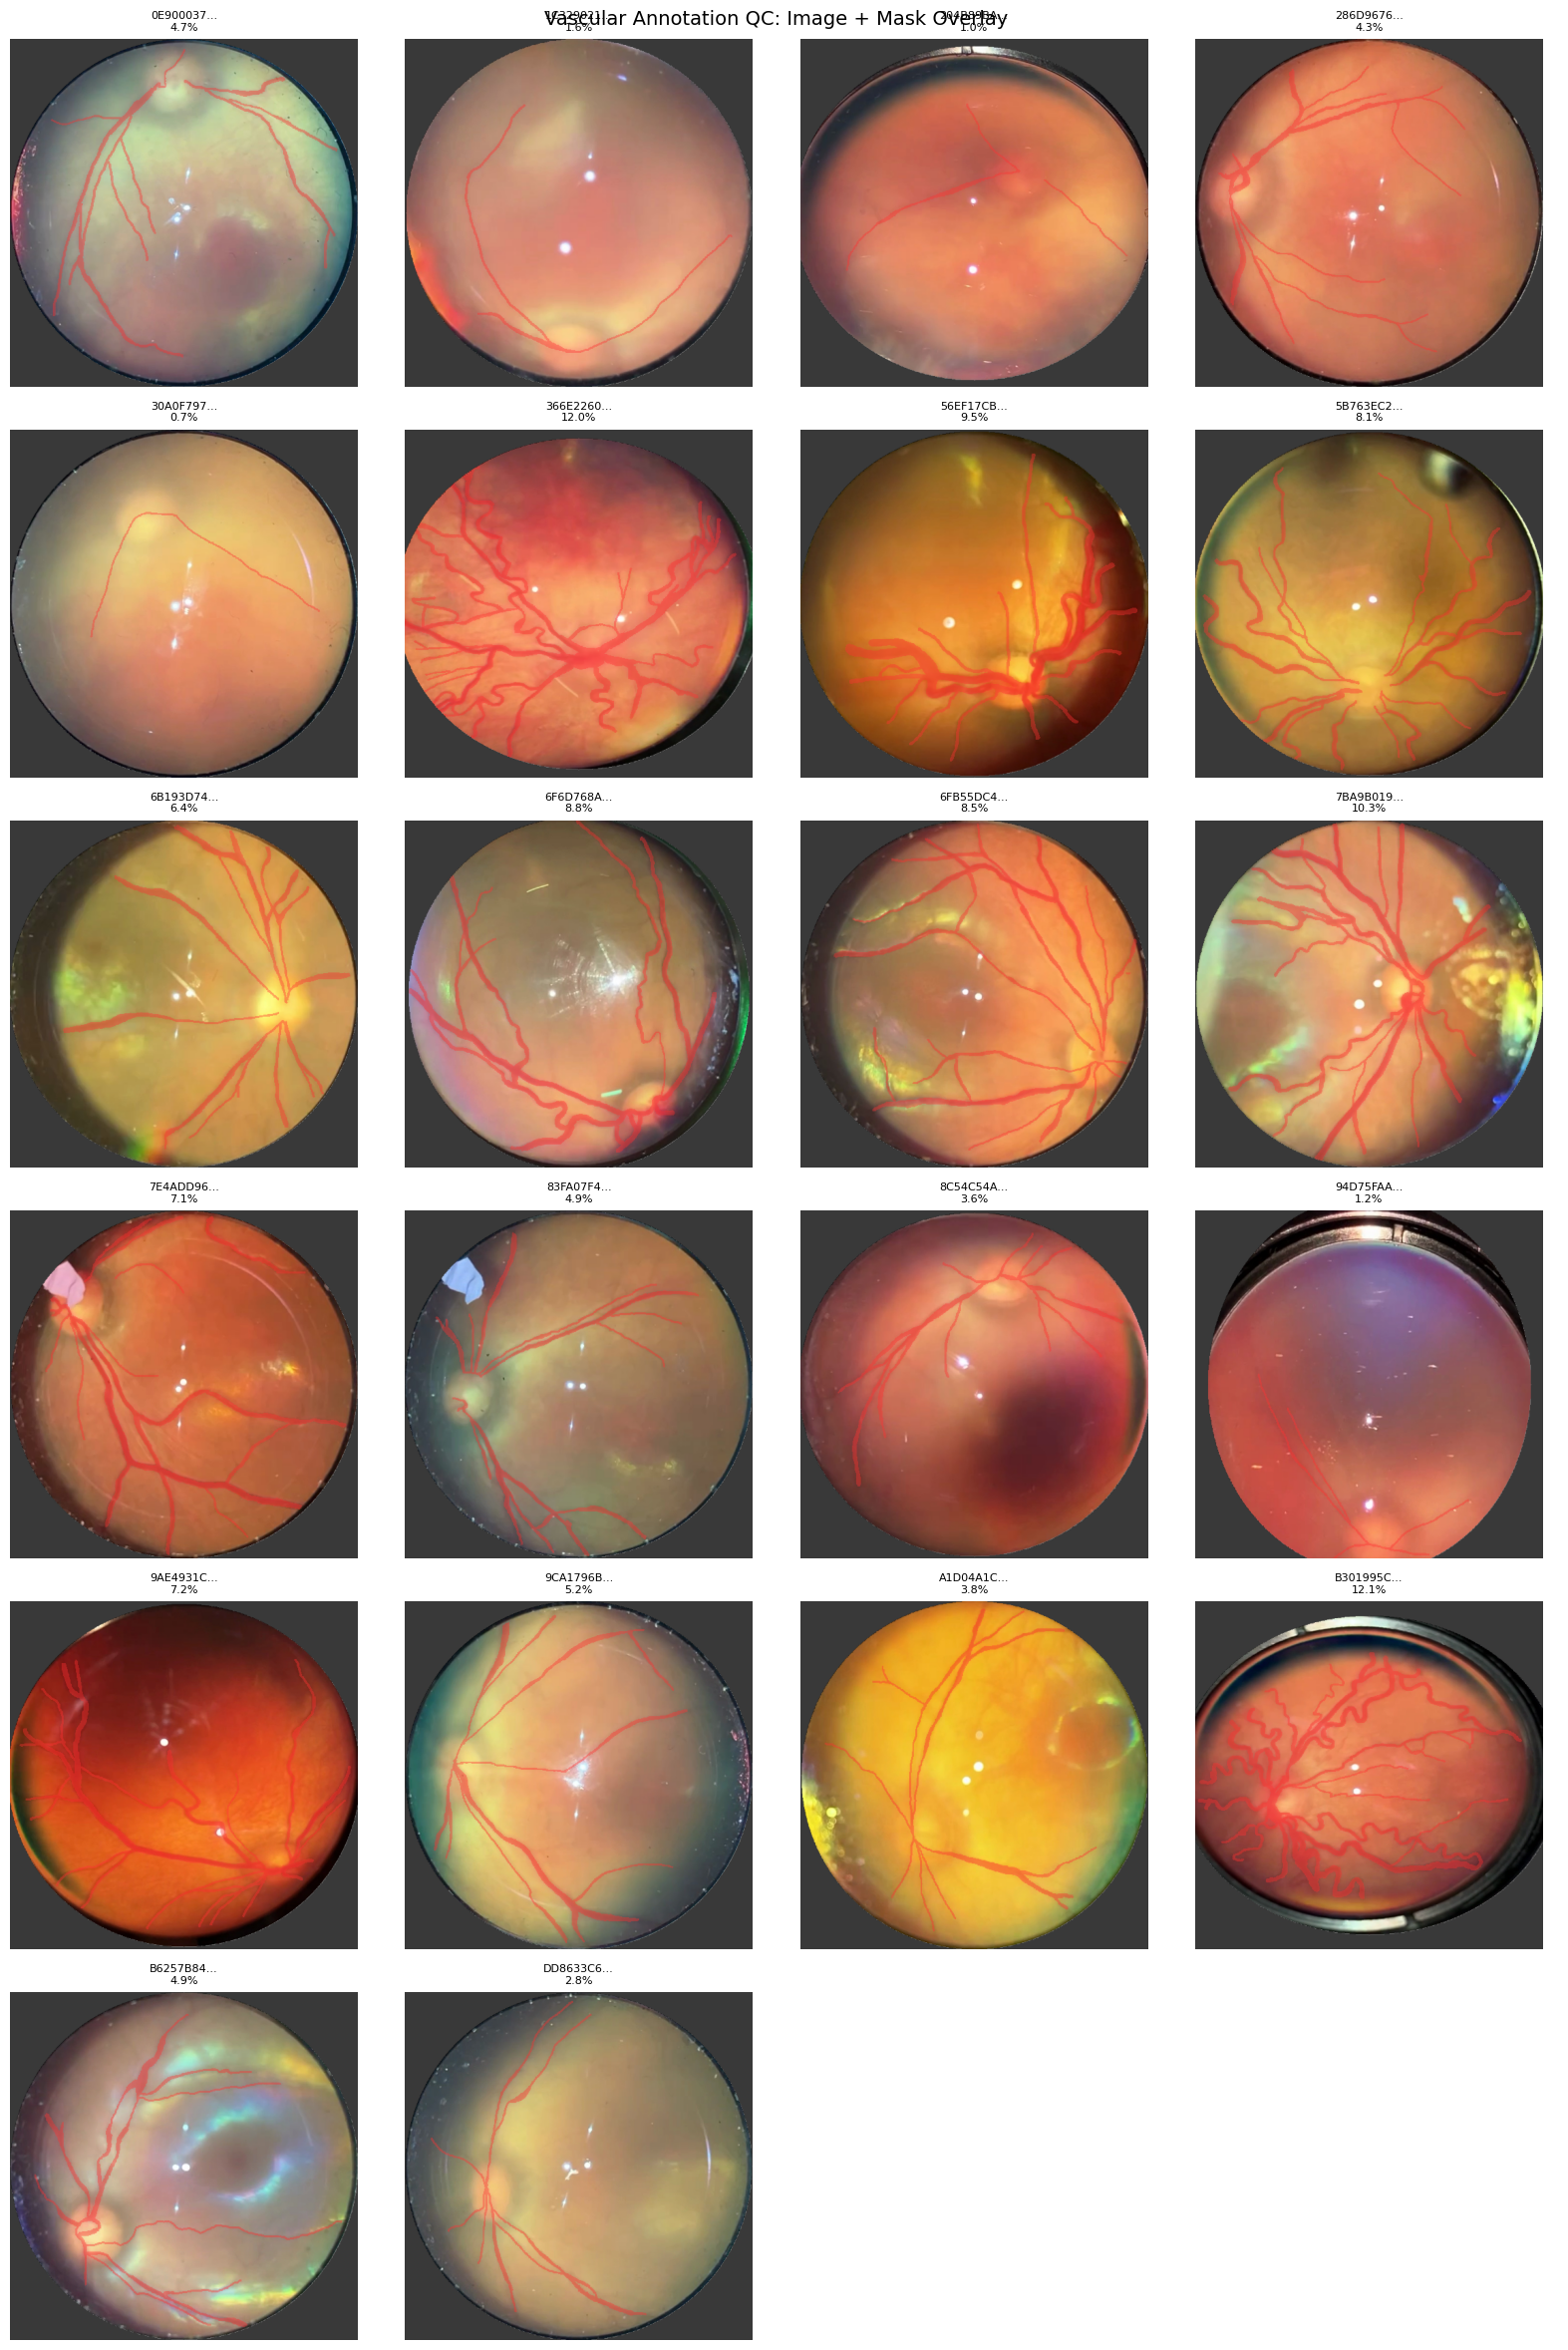

In [6]:
output_images = sorted(OUTPUT_IMG_DIR.glob('*.png'))
n = len(output_images)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for idx, img_path in enumerate(output_images):
    stem = img_path.stem
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(OUTPUT_MASK_DIR / f'{stem}.png'), cv2.IMREAD_GRAYSCALE)
    circle = cv2.imread(str(OUTPUT_CIRCLE_DIR / f'{stem}.png'), cv2.IMREAD_GRAYSCALE)
    
    # Create overlay: red for vessels
    overlay = img_rgb.copy()
    overlay[mask > 0] = [255, 50, 50]
    blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)
    # Dim outside circle
    blended[circle == 0] = blended[circle == 0] // 2
    
    vessel_pct = 100 * np.sum(mask > 0) / np.sum(circle > 0) if np.sum(circle > 0) > 0 else 0
    axes[idx].imshow(blended)
    axes[idx].set_title(f'{stem[:8]}...\n{vessel_pct:.1f}%', fontsize=8)
    axes[idx].axis('off')

# Hide empty axes
for idx in range(n, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Vascular Annotation QC: Image + Mask Overlay', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Verify output counts
n_img = len(list(OUTPUT_IMG_DIR.glob('*.png')))
n_mask = len(list(OUTPUT_MASK_DIR.glob('*.png')))
n_circle = len(list(OUTPUT_CIRCLE_DIR.glob('*.png')))
print(f'Output files: images={n_img}, masks={n_mask}, circle_masks={n_circle}')
assert n_img == n_mask == n_circle == 22, f'Expected 22 files each, got {n_img}/{n_mask}/{n_circle}'
print('All checks passed!')

Output files: images=22, masks=22, circle_masks=22
All checks passed!
